In [1]:
import jax
import flax

import jax.numpy as jnp
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from IPython.display import clear_output
from jax.nn.initializers import normal as normal_init
from jax.nn.initializers import he_normal
from flax import linen as nn

from flax.training import train_state
import optax

class TrainState(train_state.TrainState):
    """Simple TrainState: we keep batch_stats outside, like your original code."""
    pass

2025-11-19 12:22:19.761260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763572939.770734  196917 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763572939.773616  196917 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763572939.782274  196917 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763572939.782283  196917 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763572939.782284  196917 computation_placer.cc:177] computation placer alr

In [2]:
def set_range(batch):
  batch = tf.image.convert_image_dtype(batch['image'], tf.float32)
  batch = (batch - 0.5) / 0.5  # tanh range is -1, 1
  return batch


mnist_data = tfds.load("mnist")['train']
batches_in_epoch = len(mnist_data) // 128

data_gen = iter(tfds.as_numpy(
      mnist_data
        .map(set_range)
        .cache()
        .shuffle(len(mnist_data), seed=41)
        .repeat()
        .batch(128)
 ))

I0000 00:00:1763572942.191097  196917 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22276 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:0a:00.0, compute capability: 8.6
I0000 00:00:1763572942.192222  196917 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22311 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:0b:00.0, compute capability: 8.6


In [3]:
from typing import Optional

class Generator(nn.Module):
    """InfoGAN generator for MNIST, based on your simple ConvTranspose stack."""
    z_dim: int = 62       # noise part
    n_cat: int = 10       # categorical code
    n_cont: int = 2       # continuous codes
    features: int = 64
    training: bool = True

    @nn.compact
    def __call__(self, z):
        """
        Args:
            z:      (B, z_dim)
            c_cat:  (B, n_cat)    one-hot
            c_cont: (B, n_cont)   e.g. 2 dims in [-1, 1]

        Returns:
            x: (B, 28, 28, 1) in [-1, 1]
        """
        # ----- concat latent pieces -----
        # reshape to (B, 1, 1, C) for conv-transpose
        z_full = z.reshape((z.shape[0], 1, 1, z.shape[1]))

        x = nn.ConvTranspose(
            self.features * 4,
            kernel_size=(3, 3),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(z_full)
        x = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(x)
        x = nn.relu(x)

        x = nn.ConvTranspose(
            self.features * 2,
            kernel_size=(4, 4),
            strides=(1, 1),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(x)
        x = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(x)
        x = nn.relu(x)

        x = nn.ConvTranspose(
            self.features,
            kernel_size=(3, 3),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(x)
        x = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(x)
        x = nn.relu(x)

        x = nn.ConvTranspose(
            1,
            kernel_size=(4, 4),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(x)
        x = jnp.tanh(x)
        return x



In [13]:
class Discriminator(nn.Module):
    """Discriminator with attached Q-network, built on your architecture."""
    features: int = 64
    training: bool = True
    q_cat: int = 10

    @nn.compact
    def __call__(self, x):
        """
        Args:
            x: (B, 28, 28, 1) in [-1, 1]

        Returns:
            d_logits:        (B, 1)         real/fake logits
            q_cat_logits:    (B, q_cat)
            q_cont_mu:       (B, q_cont) or None
            q_cont_logsigma: (B, q_cont) or None
        """
        # ----- shared backbone -----
        h = nn.Conv(
            self.features,
            kernel_size=(4, 4),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(x)
        h = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(h)
        h = nn.leaky_relu(h, 0.2)

        h = nn.Conv(
            self.features * 2,
            kernel_size=(4, 4),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(h)
        h = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(h)
        h = nn.leaky_relu(h, 0.2)

        # At this point the spatial size is 5x5; next heads go from there.

        # ----- D head -----
        d = nn.Conv(
            1,
            kernel_size=(4, 4),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(h)        # -> (B, 1, 1, 1)
        d = d.reshape((d.shape[0], -1))  # (B, 1)
        d_logits = d  # treat as logits; apply sigmoid in loss if desired

        # ----- Q trunk -----
        q = nn.Conv(
            self.features * 2,
            kernel_size=(4, 4),
            strides=(2, 2),
            padding='VALID',
            kernel_init=normal_init(0.02),
        )(h)        # -> (B, 1, 1, 2*features)
        q = nn.BatchNorm(
            use_running_average=not self.training,
            axis=-1,
            momentum=0.1,
            scale_init=normal_init(0.02),
        )(q)
        q = nn.leaky_relu(q, 0.2)
        q = q.reshape((q.shape[0], -1))  # (B, 2*features)

        # ----- Q categorical head -----
        q_cat_logits = nn.Dense(
            self.q_cat,
            kernel_init=normal_init(0.02),
        )(q)

        return d_logits, q_cat_logits


In [5]:
class Generator(nn.Module):
  features: int = 72
  training: bool = True

  @nn.compact
  def __call__(self, z):
    z = z.reshape((z.shape[0], 1, 1, z.shape[1]))
    x = nn.ConvTranspose(self.features*4, [3, 3], [2, 2], 'VALID', kernel_init=he_normal(), use_bias=False)(z)
    x = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(x)
    x = nn.leaky_relu(x,0.2)
    x = nn.ConvTranspose(self.features*2, [4, 4], [1, 1], 'VALID', kernel_init=he_normal(), use_bias=False)(x)
    x = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(x)
    x = nn.leaky_relu(x,0.2)
    x = nn.ConvTranspose(self.features, [3, 3], [2, 2], 'VALID', kernel_init=he_normal(), use_bias=False)(x)
    x = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(x)
    x = nn.leaky_relu(x,0.2)
    x = nn.ConvTranspose(1, [4, 4], [2, 2], 'VALID', kernel_init=normal_init(0.01))(x)
    x = jnp.tanh(x)
    return x

class Discriminator(nn.Module):
  features: int = 72
  training: bool = True
  q_cat: int = 10

  @nn.compact
  def __call__(self, x):
    x = nn.Conv(self.features, [4, 4], [2, 2], 'VALID', kernel_init=normal_init(0.02))(x)
    x = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(x)
    x = nn.leaky_relu(x, 0.2)

    x = nn.Conv(self.features*2, [4, 4], [2, 2], 'VALID', kernel_init=normal_init(0.02))(x)
    x = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(x)
    x = nn.leaky_relu(x, 0.2)

    # Discriminator output
    d = nn.Conv(1, [4, 4], [2, 2], 'VALID', kernel_init=normal_init(0.02))(x)
    d = d.reshape((d.shape[0], -1))

    # Q network
    q_feat = nn.Conv(self.features*2, [4, 4], [2, 2], 'VALID', kernel_init=normal_init(0.02))(x)
    q_feat = nn.BatchNorm(not self.training, -1, 0.1, scale_init=normal_init(0.02))(q_feat)
    q_feat = nn.leaky_relu(q_feat, 0.2)

    q_flat = q_feat.reshape((q_feat.shape[0], -1))
    
    # Global average pool spatial dims
    q_feat_avg = jnp.mean(q_feat, axis=(1, 2))      # (B, C)

    # Map to logits over 10 categories
    q_logits = nn.Dense(self.q_cat, kernel_init=normal_init(0.02))(q_feat_avg)  # (B, 10)
    
    return d, q_logits

In [5]:
def sample_latent(key, shape_noise, shape_cat):
  noise_key, cat_key = jax.random.split(key, 2)

  # Sample irreducible noise
  noise = jax.random.normal(noise_key, shape_noise)

  # Sample categorical latent code
  code_cat = jax.random.randint(cat_key, shape_cat, 0, 10)
  code_cat = jax.nn.one_hot(code_cat, 10)

  latent = jnp.concatenate([noise, code_cat], axis=-1)

  return latent, code_cat

In [6]:
def bce_logits(logit, label):
  """
  Implements the BCE with logits loss, as described:
  https://github.com/pytorch/pytorch/issues/751
  """
  neg_abs = -jnp.abs(logit)
  batch_bce = jnp.maximum(logit, 0) - logit * label + jnp.log(1 + jnp.exp(neg_abs))
  return jnp.mean(batch_bce)


def loss_mutual_information(code_cat, q_cat):
  cat_loss = -jnp.mean(jnp.sum(code_cat * q_cat, axis=-1))
  mi_loss = cat_loss
  return mi_loss


def loss_generator(params_g, params_d, vars_g, vars_d, data, key):
  batch_size = data.shape[0]
  latent, code_cat = sample_latent(key, (batch_size, 64), (batch_size, ))

  fake_data, vars_g = Generator().apply(
      {'params': params_g, 'batch_stats': vars_g['batch_stats']},
      latent, mutable=['batch_stats']
  )

  (preds, q), vars_d = Discriminator().apply(
      {'params': params_d, 'batch_stats': vars_d['batch_stats']},
      fake_data, mutable=['batch_stats']
  )

  # Calculate Mutual Information loss
  q_cat = nn.log_softmax(q, axis=-1)
  loss_mi = loss_mutual_information(code_cat, q_cat)

  # Calculate Discriminator loss
  loss_d = -jnp.mean(jnp.log(nn.sigmoid(preds)))

  loss = loss_d + loss_mi
  return loss, (vars_g, vars_d)


def loss_discriminator(params_d, params_g, vars_g, vars_d, data, key):
  batch_size = data.shape[0]
  latent, code_cat = sample_latent(key, (batch_size, 64), (batch_size, ))

  fake_data, vars_g = Generator().apply(
      {'params': params_g, 'batch_stats': vars_g['batch_stats']},
      latent, mutable=['batch_stats']
  )

  (fake_preds, q), vars_d = Discriminator().apply(
      {'params': params_d, 'batch_stats': vars_d['batch_stats']},
      fake_data, mutable=['batch_stats']
  )
  (real_preds, _), vars_d = Discriminator().apply(
      {'params': params_d, 'batch_stats': vars_d['batch_stats']},
      data, mutable=['batch_stats']
  )

  # Calculate Mutual Information loss
  q_cat = nn.log_softmax(q, axis=-1)
  loss_mi = loss_mutual_information(code_cat, q_cat)

  real_loss = bce_logits(real_preds, jnp.ones((batch_size,), dtype=jnp.int32))
  fake_loss = bce_logits(fake_preds, jnp.zeros((batch_size,), dtype=jnp.int32))

  loss = (real_loss + fake_loss) / 2 + loss_mi

  return loss, (vars_g, vars_d)

In [7]:
@jax.jit
def train_step(data, vars_g, vars_d, g_state, d_state, key):
  # Same key usage as before
  key, key_gen, key_disc = jax.random.split(key, 3)

  # === 1) Train discriminator (same pattern as your original) ===
  grad_fn_discriminator = jax.value_and_grad(loss_discriminator, has_aux=True)
  (loss_d, (vars_g, vars_d)), grad_d = grad_fn_discriminator(
      d_state.params,  # params_d
      g_state.params,  # params_g
      vars_g,
      vars_d,
      data,
      key_disc,
  )
  d_state = d_state.apply_gradients(grads=grad_d)

  # === 2) Train generator ===
  grad_fn_generator = jax.value_and_grad(loss_generator, has_aux=True)
  (loss_g, (vars_g, vars_d)), grad_g = grad_fn_generator(
      g_state.params,  # params_g
      d_state.params,  # params_d (updated)
      vars_g,
      vars_d,
      data,
      key_gen,
  )
  g_state = g_state.apply_gradients(grads=grad_g)

  loss = {'generator': loss_g, 'discriminator': loss_d}
  return loss, vars_g, vars_d, g_state, d_state, key

In [8]:
def plot(images, loss, epoch):
  clear_output(True)

  # First plot the losses.
  fig, ax = plt.subplots(figsize=(10, 4))
  ax.plot(loss['generator'], label='Generator Loss')
  ax.plot(loss['discriminator'], label='Discriminator Loss')
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  fig.suptitle(f"Epoch {epoch}")

  # Next, plot the static samples.
  fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(10, 10), tight_layout=bool)
  for ax, image in zip(sum(axes.tolist(), []), images):
    ax.imshow(image[:, :, 0], cmap='gray')
    ax.set_axis_off()

  plt.show()

In [9]:
@jax.jit
def eval_step(params, vars_g, latent):
  fake_data, _ = Generator(training=False).apply(
      {'params': params, 'batch_stats': vars_g['batch_stats']},
      latent,
      mutable=['batch_stats']   # keep this to behave like your original
  )
  return fake_data

In [14]:
# RNG
key = jax.random.PRNGKey(seed=41)
key, key_gen, key_disc, key_latent = jax.random.split(key, 4)

# Retrieve shapes for generator and discriminator input.
noise = jax.random.normal(key_latent, (100, 64))
c = jnp.tile(jnp.arange(10), 10)
c = jax.nn.one_hot(c, 10)
latent = jnp.concatenate([noise, c], axis=-1)
image_shape = next(data_gen).shape  # same as before

# Generate initial variables (parameters and batch statistics).
vars_g = Generator().init(key_gen, jnp.ones(latent.shape, jnp.float32))
vars_d = Discriminator().init(key_disc, jnp.ones(image_shape, jnp.float32))

# Create Optax optimizers matching your old hyperparams.
g_tx = optax.adam(learning_rate=0.0001, b1=0.5, b2=0.999)
d_tx = optax.adam(learning_rate=0.0002, b1=0.5, b2=0.999)

# Wrap params in TrainState (params only; batch_stats remain in vars_g / vars_d)
g_state = TrainState.create(
    apply_fn=Generator().apply,    # unused here but required by TrainState
    params=vars_g['params'],
    tx=g_tx,
)

d_state = TrainState.create(
    apply_fn=Discriminator().apply,
    params=vars_d['params'],
    tx=d_tx,
)

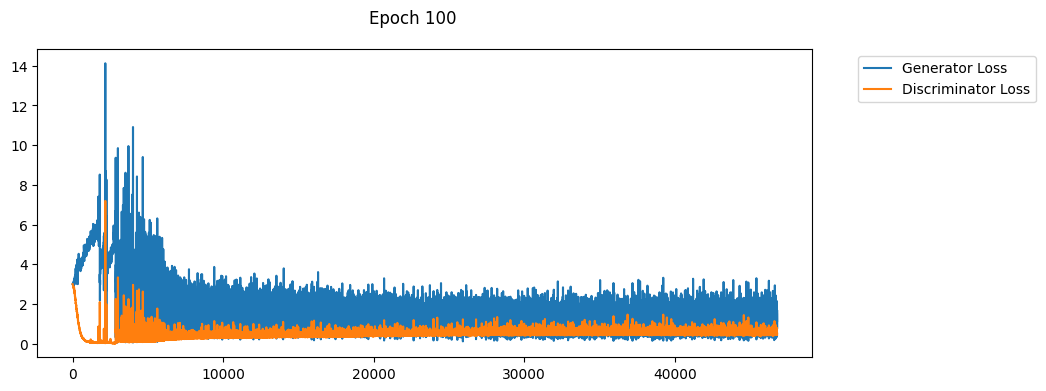

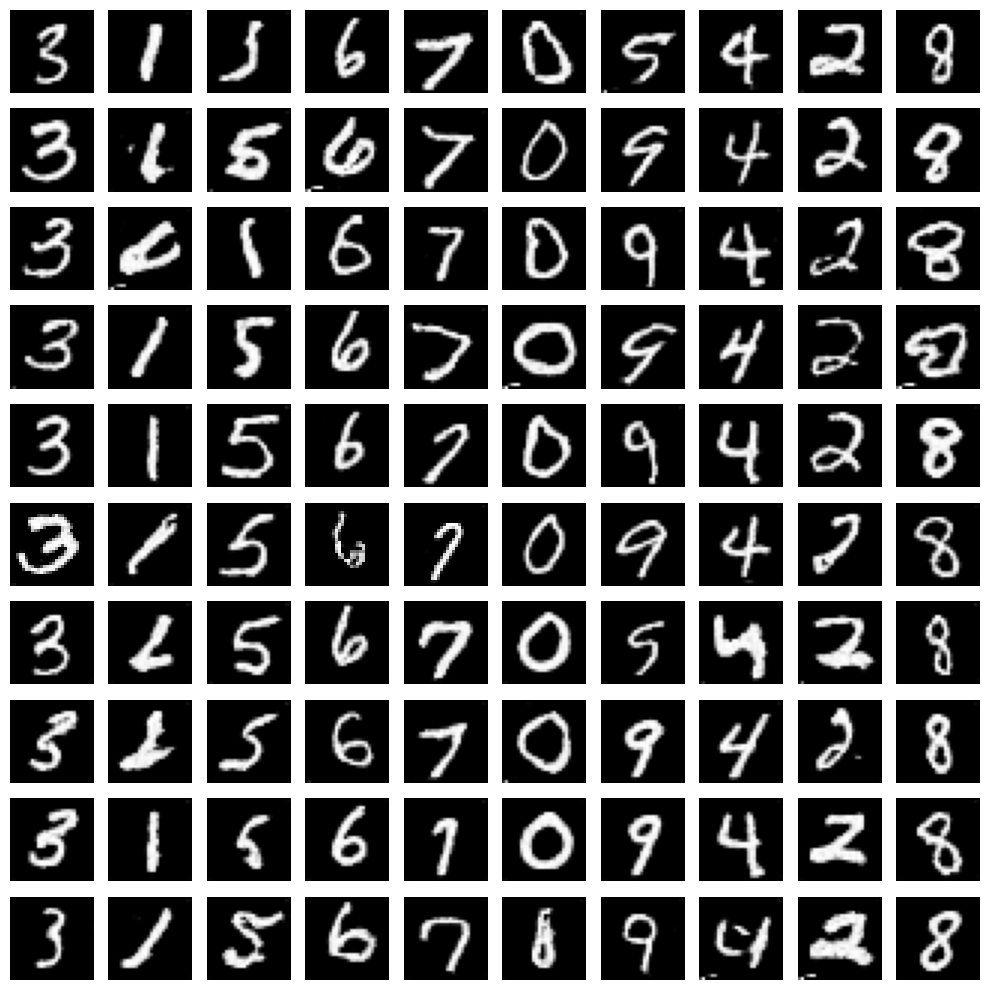

In [15]:
loss_history = {'generator': [], 'discriminator': []}

for epoch in range(1, 101):
  for batch in range(batches_in_epoch):
    data = next(data_gen)

    batch_loss, vars_g, vars_d, g_state, d_state, key = train_step(
        data, vars_g, vars_d, g_state, d_state, key
    )

    loss_history['generator'].append(batch_loss['generator'])
    loss_history['discriminator'].append(batch_loss['discriminator'])

  # eval: use g_state.params (like optim_g.target) and current vars_g
  sample = eval_step(g_state.params, vars_g, latent)
  plot(sample, loss_history, epoch)